<a href="https://colab.research.google.com/github/trxmaschine/homewrks/blob/main/01_flights_eda_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 1. EDA реестра выполненных рейсов

В этой тетрадке нужно познакомиться с реестром рейсов: проверить качество данных, посчитать описательные статистики и ответить на вопросы с помощью таблиц и графиков.

Работайте только с `data/flights_train.csv`. Файл `data/flights_test.csv` понадобится в следующих частях только для финальной проверки моделей.


In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


In [ ]:
import gdown
from collections import namedtuple

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

File = namedtuple('File', ['gdrive_id', 'name'])
FILES = [
    File("1TKvirbrgoXKZhFOTNzigcfFMDgNI9-Cj", "flights_train.csv"),
    File("1Gg8FhOTzNaExS9xMyzIoNzKMXZKlpSaG", "flights_test_classification.csv"),
    File("1TGuBv32FwCXKtsS-3u--ttFcsZMn2kWL", "flights_test_regression.csv")
]

for file in FILES:
    output_path = DATA_DIR / file.name
    gdown.download(id=file.gdrive_id, output=str(output_path), quiet=False)

In [22]:
DATA_PATH = DATA_DIR / "flights_train.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["scheduled_time", "actual_time", "block_time"],
)

df.head()


,flight_id,movement_type,flight_number,airline_code,airport_code,route,aircraft_registration,scheduled_time,actual_time,block_time,delay_minutes,is_delayed_30min,scheduled_date,scheduled_hour,scheduled_dayofweek,layout,capacity,passengers_served,adults,children,infants,class_1,class_2,class_3,mtow_tons,aircraft_type,avk,direction,category,baggage_weight,spot_number,load_factor
0,1,departure,DP 204,DP,VKO,ВНУКОВО,RA73232,2024-12-31 19:30:00,2025-01-01 00:01:00,2024-12-31 23:53:00,271.0,1,2024-12-31,19,1,Y189,189.0,115.0,107.0,8.0,0.0,0.0,0.0,115.0,75.296,73H,1.0,Domestic,J,143.0,106A,0.608466
1,2,arrival,DP 572,DP,KUF,САМАРА,RA73305,2024-12-31 23:10:00,2025-01-01 04:36:00,2025-01-01 04:45:00,326.0,1,2024-12-31,23,1,Y189,189.0,180.0,169.0,11.0,3.0,0.0,0.0,180.0,75.296,73H,1.0,Domestic,J,245.0,106A,0.952381
2,3,departure,FZ 992,FZ,DXB,ДУБАЙ,A6FMJ,2025-01-01 00:25:00,2025-01-01 01:03:00,2025-01-01 00:50:00,38.0,1,2025-01-01,0,2,174,166.0,132.0,115.0,17.0,1.0,0.0,0.0,132.0,82.190,7M8,1.0,International,J,1396.0,104B,0.795181
3,4,departure,2S 204,2S,AYT,АНТАЛЬЯ,TCGRA,2025-01-01 01:30:00,2025-01-01 02:05:00,2025-01-01 01:46:00,35.0,1,2025-01-01,1,2,Y345,312.0,342.0,288.0,54.0,0.0,0.0,0.0,342.0,233.000,332,1.0,International,J,3881.0,105,1.096154
4,5,departure,SU 734,SU,SSH,ШАРМ-ЭЛЬ-ШЕЙХ,73785,2025-01-01 04:00:00,2025-01-01 04:19:00,2025-01-01 04:04:00,19.0,0,2025-01-01,4,2,C28Y268,296.0,283.0,248.0,35.0,2.0,0.0,23.0,260.0,230.000,333,1.0,International,J,3243.0,103,0.956081


## 0. Первичный осмотр

Заполните пропуски в ячейках ниже: размер таблицы, типы колонок, доли пропусков и период наблюдений.


In [7]:
# TODO: выведите размер таблицы
rows = df.shape[0]
cols = df.shape[1]
print(f"Строк: {rows}, Столбцов: {cols}")


Строк: 9039, Столбцов: 32


In [5]:
# TODO: выведите типы колонок
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9039 entries, 0 to 9038
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   flight_id              9039 non-null   int64         
 1   movement_type          9039 non-null   object        
 2   flight_number          9039 non-null   object        
 3   airline_code           9039 non-null   object        
 4   airport_code           9039 non-null   object        
 5   route                  9017 non-null   object        
 6   aircraft_registration  9039 non-null   object        
 7   scheduled_time         9039 non-null   datetime64[ns]
 8   actual_time            9039 non-null   datetime64[ns]
 9   block_time             9039 non-null   datetime64[ns]
 10  delay_minutes          9039 non-null   float64       
 11  is_delayed_30min       9039 non-null   int64         
 12  scheduled_date         9039 non-null   object        
 13  sch

In [31]:
# TODO: посчитайте долю пропусков по колонкам и отсортируйте по убыванию
missing_share = (df.isna().sum() / len(df)).sort_values(ascending=False)
#missing_share.head(10)
display(missing_share.head(10).to_frame("missing_share"))


,missing_share
baggage_weight,0.002655
route,0.002434
layout,0.001438
passengers_served,0.000221
load_factor,0.000221
airline_code,0.000000
flight_number,0.000000
flight_id,0.000000
scheduled_time,0.000000
actual_time,0.000000


In [23]:
# TODO: найдите минимальную и максимальную дату planned/scheduled рейса
date_min = min(df["scheduled_date"])
date_max = max(df["scheduled_date"])
date_min, date_max


('2024-12-31', '2025-01-24')

## 1. Сколько в среднем рейсов в день есть в реестре?


In [27]:
# TODO: сгруппируйте рейсы по scheduled_date и посчитайте число рейсов

flights_per_day = df.groupby('scheduled_date')['flight_id'].count()
flights_per_day.describe()


,flight_id
count,25.000000
mean,361.560000
std,101.735392
min,2.000000
25%,313.000000
50%,351.000000
75%,446.000000
max,490.000000


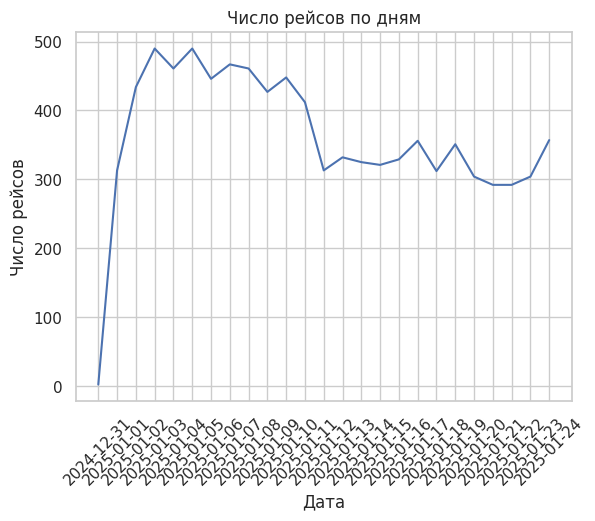

In [30]:
# TODO: постройте линейный график числа рейсов по дням

plt.plot(flights_per_day.index, flights_per_day.values)
plt.title("Число рейсов по дням")
plt.xlabel("Дата")
plt.ylabel("Число рейсов")
plt.xticks(rotation=45)
plt.show()


## 2. Каких рейсов больше: вылетов или прилетов?


In [ ]:
# TODO: посчитайте долю departure/arrival
movement_share = ____
movement_share
(df.isna().sum() / len(df)).sort_values(ascending=False)

In [ ]:
# TODO: визуализируйте распределение movement_type
____
plt.title("Вылеты и прилеты")
plt.xlabel("")
plt.ylabel("Число рейсов")
plt.show()


## 3. Какие аэропорты/маршруты самые частые, а какие самые редкие?


In [ ]:
# TODO: найдите top-10 airport_code по числу рейсов
top_airports = ____
top_airports


In [ ]:
# TODO: найдите аэропорты, встретившиеся ровно один раз
rare_airports = ____
rare_airports.head(20), len(rare_airports)


## 4. В какие часы суток рейсов больше всего?


In [ ]:
# TODO: посчитайте число рейсов по scheduled_hour
hourly = ____

plt.figure(figsize=(10, 4))
____
plt.title("Распределение рейсов по часам")
plt.xlabel("Час суток")
plt.ylabel("Число рейсов")
plt.show()


## 5. Есть ли различия между Domestic и International?

Сравните количество рейсов, пассажиропоток и загрузку.


In [ ]:
# TODO: сгруппируйте по direction и посчитайте число рейсов, среднее число пассажиров и среднюю загрузку
direction_stats = ____
direction_stats


## 6. Как распределено число пассажиров на рейс?


In [ ]:
# TODO: постройте histogram passengers_served
____
plt.title("Распределение числа пассажиров")
plt.xlabel("Пассажиры")
plt.ylabel("Число рейсов")
plt.show()


In [ ]:
# TODO: посчитайте основные квантили passengers_served
____


## 7. Насколько часто рейсы заполнены почти полностью?

Используйте `load_factor = passengers_served / capacity`. Подумайте, как обработать значения больше 1.


In [ ]:
# TODO: посчитайте долю рейсов с load_factor >= 0.9
high_load_share = ____
high_load_share


In [ ]:
# TODO: найдите маршруты с самой высокой средней загрузкой, оставив маршруты с >= 20 рейсами
route_load = ____
route_load.head(10)


## 8. Как распределены задержки и какова доля задержек больше 30 минут?


In [ ]:
# TODO: постройте histogram delay_minutes
____
plt.title("Распределение задержек")
plt.xlabel("Задержка, минуты")
plt.ylabel("Число рейсов")
plt.show()


In [ ]:
# TODO: посчитайте долю рейсов с is_delayed_30min == 1
delay_share = ____
delay_share


## 9. Какие направления чаще задерживаются?

Сравните аэропорты или маршруты, где есть не менее 30 рейсов.


In [ ]:
# TODO: посчитайте delay_rate по airport_code, оставив аэропорты с >= 30 рейсами
airport_delay = ____
airport_delay.head(10)


## 10. Связаны ли тип ВС, вместимость и пассажиропоток?


In [ ]:
# TODO: сгруппируйте по aircraft_type и сравните capacity/passengers_served/load_factor
aircraft_stats = ____
aircraft_stats.head(15)


In [ ]:
# TODO: постройте scatter capacity vs passengers_served с цветом по direction
____
plt.title("Вместимость и пассажиры")
plt.xlabel("Вместимость")
plt.ylabel("Пассажиры")
plt.show()


## Итог

Коротко ответьте на 5-7 предложений:

- что самое неожиданное вы увидели в данных;
- какие признаки выглядят полезными для предсказания задержки;
- какие признаки выглядят полезными для предсказания числа пассажиров;
- где есть риск утечек данных.
